##Step 2: Data Collection

###Import Necessary Libraries

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,precision_score,recall_score,roc_curve,roc_auc_score
import warnings
warnings.filterwarnings('ignore')

###Load Dataset

In [ ]:
breast_cancer_data =  load_breast_cancer()
breast_cancer_data

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

In [ ]:
breast_cancer_data_df = pd.DataFrame(breast_cancer_data.data, columns=breast_cancer_data['feature_names'])
breast_cancer_data_df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


##Step 3: Data Understanding

###Perform Initial Investigation

In [ ]:
breast_cancer_data_df.shape

(569, 30)

In [ ]:
breast_cancer_data_df.isna().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [ ]:
breast_cancer_data_df.dtypes

,0
mean radius,float64
mean texture,float64
mean perimeter,float64
mean area,float64
mean smoothness,float64
mean compactness,float64
mean concavity,float64
mean concave points,float64
mean symmetry,float64
mean fractal dimension,float64


In [ ]:
breast_cancer_data_df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


##Step 4: Data Preparation

### Data Transformation and separation of input and output features

In [ ]:
breast_cancer_data_df['target'] = breast_cancer_data.target

In [ ]:
X = breast_cancer_data_df.drop(columns='target')
X

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [ ]:
y = breast_cancer_data_df['target']
y

,target
0,0
1,0
2,0
3,0
4,0
...,...
564,0
565,0
566,0
567,0


In [ ]:
std_scaler = StandardScaler()
scaled_X = std_scaler.fit_transform(X)
pd.DataFrame(scaled_X, columns= breast_cancer_data.feature_names)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,2.110995,0.721473,2.060786,2.343856,1.041842,0.219060,1.947285,2.320965,-0.312589,-0.931027,...,1.901185,0.117700,1.752563,2.015301,0.378365,-0.273318,0.664512,1.629151,-1.360158,-0.709091
565,1.704854,2.085134,1.615931,1.723842,0.102458,-0.017833,0.693043,1.263669,-0.217664,-1.058611,...,1.536720,2.047399,1.421940,1.494959,-0.691230,-0.394820,0.236573,0.733827,-0.531855,-0.973978
566,0.702284,2.045574,0.672676,0.577953,-0.840484,-0.038680,0.046588,0.105777,-0.809117,-0.895587,...,0.561361,1.374854,0.579001,0.427906,-0.809587,0.350735,0.326767,0.414069,-1.104549,-0.318409
567,1.838341,2.336457,1.982524,1.735218,1.525767,3.272144,3.296944,2.658866,2.137194,1.043695,...,1.961239,2.237926,2.303601,1.653171,1.430427,3.904848,3.197605,2.289985,1.919083,2.219635


In [ ]:
features =['mean radius','mean texture']

In [ ]:
X_visual = breast_cancer_data_df[features]
y_visual = breast_cancer_data_df['target']

##Step 5: Model Building

###Train Test Split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(scaled_X, y, test_size=0.2 ,random_state=13 ,shuffle=True, stratify=y)


In [ ]:
X_train.shape,y_train.shape


((455, 30), (455,))

In [ ]:
X_test.shape,y_test.shape

((114, 30), (114,))

In [ ]:
X_train_visual,X_test_visual,y_train_visual,y_test_visual = train_test_split(X_visual,y_visual,test_size=0.2,random_state=13,shuffle=True,stratify=y)

In [ ]:
X_train_visual = std_scaler.fit_transform(X_train_visual)
X_test_visual = std_scaler.transform(X_test_visual)

###Model Initialization

In [ ]:
svm_classifier = SVC(kernel='linear',probability=True)

In [ ]:
svm_classifier_2 = SVC(kernel='rbf',C=1,gamma='scale',probability=True)

In [ ]:
svm_classifier_3 = SVC(kernel='poly',C=1,gamma='scale',degree=3,probability=True)

In [ ]:
svm_classifier_4 = SVC(kernel='sigmoid',gamma='scale',probability=True)

In [ ]:
svm = SVC(kernel='linear',C=1)

##Step 6: Model Training

In [ ]:
svm_classifier.fit(X_train,y_train)

SVC(kernel='linear', probability=True)

In [ ]:
svm_classifier_2.fit(X_train,y_train)

SVC(probability=True)

In [ ]:
svm_classifier_3.fit(X_train,y_train)

SVC(C=1, kernel='poly', probability=True)

In [ ]:
svm_classifier_4.fit(X_train,y_train)

SVC(kernel='sigmoid', probability=True)

In [ ]:
svm.fit(X_train_visual,y_train_visual)

SVC(C=1, kernel='linear')

##Step 7: Model Testing

###Training Data Prediction

In [ ]:
y_pred_train = svm_classifier.predict(X_train)

In [ ]:
y_pred_rbf_train = svm_classifier_2.predict(X_train)

In [ ]:
y_pred_poly_train = svm_classifier_3.predict(X_train)

In [ ]:
y_pred_sig_train = svm_classifier_4.predict(X_train)

In [ ]:
y_pred_train

array([1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0,
       1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,

###Test Data Prediction

In [ ]:
y_pred_test = svm_classifier.predict(X_test)

In [ ]:
y_pred_rbf_test = svm_classifier_2.predict(X_test)

In [ ]:
y_pred_poly_test = svm_classifier_3.predict(X_test)

In [ ]:
y_pred_sig_test = svm_classifier_4.predict(X_test)

In [ ]:
y_pred_test

array([0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1])

##Step 8: Model Evaluation

###Training Data Evaluation

In [ ]:
print('accuracy_score:',accuracy_score(y_train,y_pred_train))
print('precision_score:',precision_score(y_train,y_pred_train))
print('recall_score:',recall_score(y_train,y_pred_train))


accuracy_score: 0.9846153846153847
precision_score: 0.986013986013986
recall_score: 0.9894736842105263


### RBF Training Evaluation



In [ ]:
print('accuracy_score:',accuracy_score(y_train,y_pred_rbf_train))
print('precision_score:',precision_score(y_train,y_pred_rbf_train))
print('recall_score:',recall_score(y_train,y_pred_rbf_train))


accuracy_score: 0.9868131868131869
precision_score: 0.979381443298969
recall_score: 1.0


###Poly Training Evaluation

In [ ]:
print('accuracy_score:',accuracy_score(y_train,y_pred_poly_train))
print('precision_score:',precision_score(y_train,y_pred_poly_train))
print('recall_score:',recall_score(y_train,y_pred_poly_train))


accuracy_score: 0.9076923076923077
precision_score: 0.8715596330275229
recall_score: 1.0


###Sig Training Evaluation

In [ ]:
print('accuracy_score:',accuracy_score(y_train,y_pred_sig_train))
print('precision_score:',precision_score(y_train,y_pred_sig_train))
print('recall_score:',recall_score(y_train,y_pred_sig_train))


accuracy_score: 0.9494505494505494
precision_score: 0.9486301369863014
recall_score: 0.9719298245614035


###ROC curve

auc_score: 0.9967595459236326


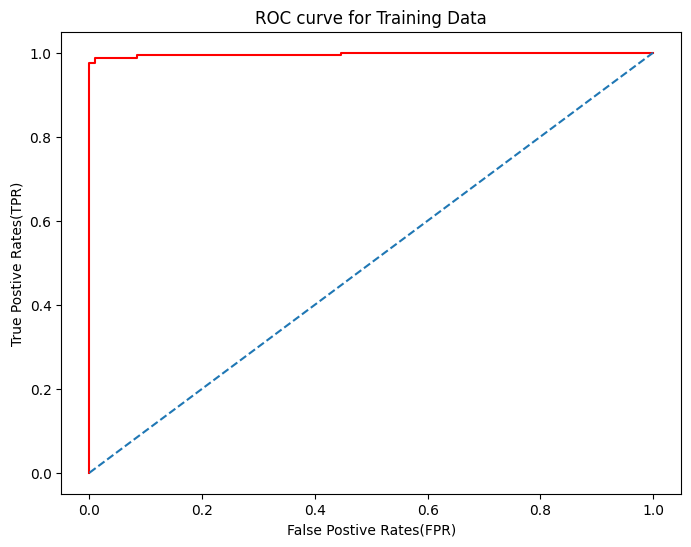

In [ ]:
y_prob = svm_classifier.predict_proba(X_train)[:,0]
fpr,tpr,threshold = roc_curve(y_train,y_prob,pos_label=0)
print('auc_score:',roc_auc_score((y_train==0).astype(int),y_prob))
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color='red')
plt.plot([0,1],[0,1],linestyle='--')
plt.title('ROC curve for Training Data')
plt.xlabel('False Postive Rates(FPR)')
plt.ylabel('True Postive Rates(TPR)')
plt.show()

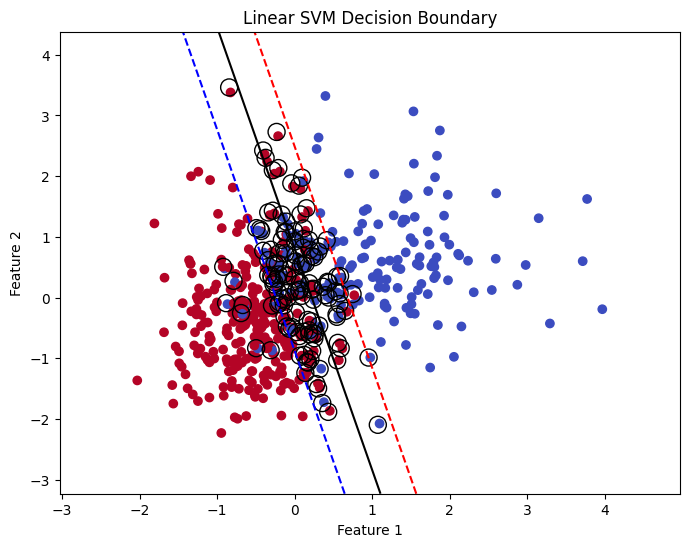

In [ ]:
plt.figure(figsize=(8,6))

# Plot Original Training Data
plt.scatter(
    X_train[:,0],          # Feature 1 (X-axis)
    X_train[:,1],          # Feature 2 (Y-axis)
    c=y_train,             # Color based on class
    cmap='coolwarm'
)

# Create 500 evenly spaced values for each feature
xx, yy = np.meshgrid(
    np.linspace(
        X_train[:,0].min()-1,
        X_train[:,0].max()+1,
        500
    ),
    np.linspace(
        X_train[:,1].min()-1,
        X_train[:,1].max()+1,
        500
    )
)

# Convert meshgrid into dataset format
grid = np.c_[xx.ravel(), yy.ravel()]

# Distance of every imaginary customer from boundary
Z = svm.decision_function(grid)

# Convert back to meshgrid shape
Z = Z.reshape(xx.shape)

# Draw Hyperplanes
plt.contour(
    xx,
    yy,
    Z,
    levels=[-1,0,1],
    colors=['red','black','blue'],
    linestyles=['--','-','--']
)

# Highlight Support Vectors
plt.scatter(
    svm.support_vectors_[:,0],
    svm.support_vectors_[:,1],
    s=150,
    facecolors='none',
    edgecolors='black'
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Linear SVM Decision Boundary")

plt.show()

###Test Data Evaluation

In [ ]:
print('accuracy_score:',accuracy_score(y_test,y_pred_test))
print('precision_score:',precision_score(y_test,y_pred_test))
print('recall_score:',recall_score(y_test,y_pred_test))


accuracy_score: 0.9736842105263158
precision_score: 0.9726027397260274
recall_score: 0.9861111111111112


auc_score: 0.996031746031746


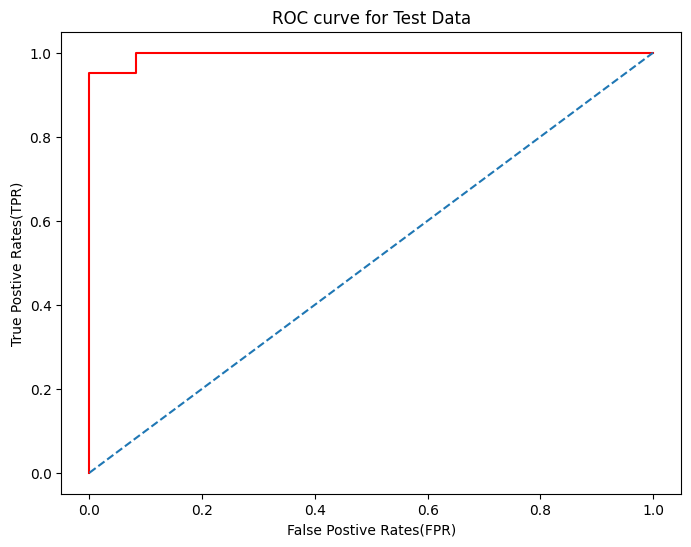

In [ ]:
y_prob = svm_classifier.predict_proba(X_test)[:,0]
fpr,tpr,threshold = roc_curve(y_test,y_prob,pos_label=0)
print('auc_score:',roc_auc_score((y_test==0).astype(int),y_prob))
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color='red')
plt.plot([0,1],[0,1],linestyle='--')
plt.title('ROC curve for Test Data')
plt.xlabel('False Postive Rates(FPR)')
plt.ylabel('True Postive Rates(TPR)')
plt.show()

###RBF Test Evaluation

In [ ]:
print('accuracy_score:',accuracy_score(y_test,y_pred_rbf_test))
print('precision_score:',precision_score(y_test,y_pred_rbf_test))
print('recall_score:',recall_score(y_test,y_pred_rbf_test))


accuracy_score: 0.9912280701754386
precision_score: 0.9863013698630136
recall_score: 1.0


###Poly Test Evaluation

In [ ]:
print('accuracy_score:',accuracy_score(y_test,y_pred_poly_test))
print('precision_score:',precision_score(y_test,y_pred_poly_test))
print('recall_score:',recall_score(y_test,y_pred_poly_test))


accuracy_score: 0.8771929824561403
precision_score: 0.8372093023255814
recall_score: 1.0


###Sig Test Evaluation

In [ ]:
print('accuracy_score:',accuracy_score(y_test,y_pred_sig_test))
print('precision_score:',precision_score(y_test,y_pred_sig_test))
print('recall_score:',recall_score(y_test,y_pred_sig_test))


accuracy_score: 0.956140350877193
precision_score: 0.958904109589041
recall_score: 0.9722222222222222
